# **Classification : Multi-Class**


## **1.환경준비**

### (1) 라이브러리 Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [3]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # long = int64
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [4]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [5]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [6]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [7]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터로딩

In [8]:
path = "https://raw.githubusercontent.com/DA4BAM/dataset/master/iris.csv"
data = pd.read_csv(path)
data.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## **2.데이터 준비**

### (1) 데이터 준비

In [9]:
target = 'Species'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

* 분류 모델링을 위해서 y는 **integer encoding**을 수행해야 함.

In [10]:
le = LabelEncoder()
y = le.fit_transform(y)
y[:5]

array([0, 0, 0, 0, 0])

In [11]:
le.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [12]:
le.inverse_transform(y)

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

### (2) 가변수화

### (3) 데이터분할

In [13]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3, random_state = 20)

### (4) Scaling

In [14]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

## **3.모델링1**

### (1) 딥러닝을 위한 준비작업

* make_DataLoader

In [15]:
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [16]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f"Shape of x [rows, columns]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [rows, columns]: torch.Size([32, 4])
Shape of y: torch.Size([32]) torch.int64


### (2) 모델 선언

In [17]:
n_feature = x.shape[1]
n_class = len(le.classes_)

# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, n_class),  # 출력층 활성화 함수를 지정하지 않음
        ).to(device)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=3, bias=True)
)


* Loss function과 Optimizer

In [18]:
loss_fn = nn.CrossEntropyLoss()       # Cross Entropy : 이 손실 함수는 내부에 SoftMax 연산이 포함(출력층 활성화함수 지정 안함)
optimizer = Adam(model.parameters(), lr=0.1)

### (3) 학습

In [19]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 0.927514, val loss : 0.874834
Epoch 2, train loss : 0.766939, val loss : 0.757612
Epoch 3, train loss : 0.693621, val loss : 0.694741
Epoch 4, train loss : 0.629961, val loss : 0.623181
Epoch 5, train loss : 0.523387, val loss : 0.582842
Epoch 6, train loss : 0.511833, val loss : 0.556203
Epoch 7, train loss : 0.473794, val loss : 0.551888
Epoch 8, train loss : 0.457253, val loss : 0.540619
Epoch 9, train loss : 0.415543, val loss : 0.492946
Epoch 10, train loss : 0.379706, val loss : 0.474665
Epoch 11, train loss : 0.408666, val loss : 0.467231
Epoch 12, train loss : 0.375047, val loss : 0.461907
Epoch 13, train loss : 0.348529, val loss : 0.444051
Epoch 14, train loss : 0.325293, val loss : 0.435665
Epoch 15, train loss : 0.336537, val loss : 0.435298
Epoch 16, train loss : 0.309781, val loss : 0.425770
Epoch 17, train loss : 0.312463, val loss : 0.417982
Epoch 18, train loss : 0.334034, val loss : 0.413019
Epoch 19, train loss : 0.310572, val loss : 0.402206
Ep

* 학습된 파라미터 확인

In [20]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Parameter: {name}, Value: {param.data}")

Parameter: 0.weight, Value: tensor([[-5.4498,  6.4036, -7.9484, -7.6276],
        [ 0.9996, -3.2125,  0.4795, -4.1000],
        [ 2.0618, -3.5415,  4.3417,  7.7820]])
Parameter: 0.bias, Value: tensor([ 5.1997,  3.8876, -6.6853])


* 학습 곡선

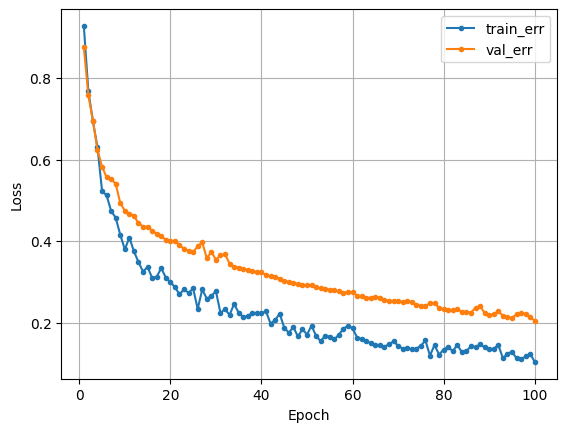

In [21]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (4) 모델 평가

* **[주의!]** 다중 분류 모델의 평가
    * ① 예측결과를
    * ② nn.Softmax함수로 변환 ==> 확률값
    * ③ 그 중 가장 큰 값의 인덱스로 변환 : np.argmax()


In [22]:
# 1. 예측결과
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

# 다중 분류의 예측 결과는 2차원 구조
pred.numpy()[:5]

array([[ 7.233406  ,  2.20015   , -7.7195835 ],
       [-3.7934446 ,  1.7238252 , -0.57478   ],
       [-3.7726965 ,  1.4723029 , -0.51572466],
       [-7.725806  ,  1.1763299 ,  1.8845601 ],
       [-2.1491776 ,  2.0649066 , -1.693975  ]], dtype=float32)

In [23]:
# 2. softmax로 변환
pred = nn.functional.softmax(pred, dim=1)
pred[:5]

tensor([[9.9352e-01, 6.4753e-03, 3.1855e-07],
        [3.6370e-03, 9.0546e-01, 9.0907e-02],
        [4.6171e-03, 8.7547e-01, 1.1991e-01],
        [4.4909e-05, 3.2998e-01, 6.6998e-01],
        [1.4243e-02, 9.6330e-01, 2.2454e-02]])

In [24]:
# 3. 가장 큰 값의 인덱스
pred = np.argmax(pred.numpy(), axis = 1)
pred[:5]

array([0, 1, 1, 2, 1])

* confusion matrix

In [25]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[13,  0,  0],
       [ 0, 18,  0],
       [ 0,  4, 10]])

* classification_report

In [26]:
le.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [27]:
print(classification_report(y_val_ts.numpy(), pred, target_names=le.classes_))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.82      1.00      0.90        18
   virginica       1.00      0.71      0.83        14

    accuracy                           0.91        45
   macro avg       0.94      0.90      0.91        45
weighted avg       0.93      0.91      0.91        45



## **4.딥러닝2 : 은닉층 추가**

### (1) 모델 선언

In [28]:
n_feature = x.shape[1]
n_class = len(le.classes_)

# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, 10),
            nn.ReLU(),
            nn.Linear(10, 5),
            nn.ReLU(),
            nn.Linear(5, n_class),
        ).to(device)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=3, bias=True)
)


* Loss function과 Optimizer

In [29]:
loss_fn = nn.CrossEntropyLoss()       # Cross Entropy : 이 손실함수는 내부에 SoftMax 연산이 포함
optimizer = Adam(model.parameters(), lr=0.01)

### (2) 학습

In [30]:
epochs = 100
tr_loss_list, val_loss_list = [], []

for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

    # 리스트에 loss 추가 --> learning curve 그리기 위해.
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

Epoch 1, train loss : 1.092143, val loss : 1.105978
Epoch 2, train loss : 1.059525, val loss : 1.073241
Epoch 3, train loss : 1.018072, val loss : 1.041457
Epoch 4, train loss : 0.976493, val loss : 1.009745
Epoch 5, train loss : 0.952237, val loss : 0.976057
Epoch 6, train loss : 0.909482, val loss : 0.932991
Epoch 7, train loss : 0.835374, val loss : 0.888108
Epoch 8, train loss : 0.774325, val loss : 0.844295
Epoch 9, train loss : 0.781569, val loss : 0.796002
Epoch 10, train loss : 0.672319, val loss : 0.740312
Epoch 11, train loss : 0.695168, val loss : 0.688777
Epoch 12, train loss : 0.585568, val loss : 0.634912
Epoch 13, train loss : 0.531074, val loss : 0.586063
Epoch 14, train loss : 0.452483, val loss : 0.547689
Epoch 15, train loss : 0.450531, val loss : 0.518596
Epoch 16, train loss : 0.378930, val loss : 0.489997
Epoch 17, train loss : 0.359232, val loss : 0.466693
Epoch 18, train loss : 0.368626, val loss : 0.441599
Epoch 19, train loss : 0.382648, val loss : 0.416809
Ep

* 학습 곡선

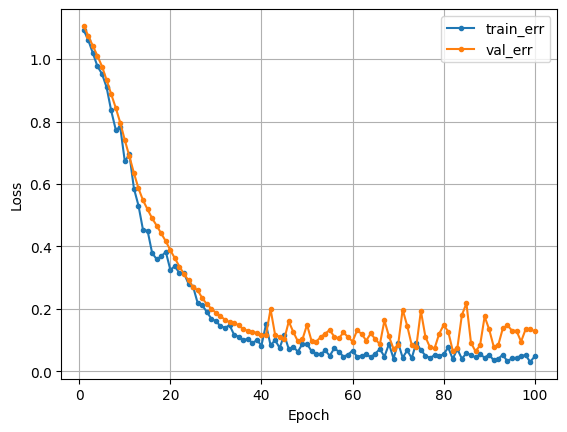

In [31]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

* **[주의!]** 다중 분류 모델의 평가
    * ① 예측결과를
    * ② nn.Softmax함수로 변환 ==> 확률값
    * ③ 그 중 가장 큰 값의 인덱스로 변환 : np.argmax()


In [32]:
# 1. 예측결과
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)

# 다중 분류의 예측 결과는 2차원 구조
pred.numpy()[:5]

array([[  8.293071  ,  -0.20767939, -14.903326  ],
       [ -4.3211856 ,   3.9613254 ,  -2.491558  ],
       [ -4.382014  ,   4.096594  ,  -2.6894937 ],
       [ -9.079365  ,   2.6917124 ,   3.3341537 ],
       [ -2.3097262 ,   3.9153183 ,  -4.35059   ]], dtype=float32)

In [33]:
# 2. softmax로 변환
pred = nn.functional.softmax(pred, dim=1)
pred[:5]

tensor([[9.9980e-01, 2.0327e-04, 8.4303e-11],
        [2.5244e-04, 9.9817e-01, 1.5731e-03],
        [2.0759e-04, 9.9866e-01, 1.1279e-03],
        [2.6627e-06, 3.4469e-01, 6.5530e-01],
        [1.9748e-03, 9.9777e-01, 2.5656e-04]])

In [34]:
# 3. 가장 큰 값의 인덱스
pred = np.argmax(pred.numpy(), axis = 1)
pred[:5]

array([0, 1, 1, 2, 1])

* confusion matrix

In [35]:
confusion_matrix(y_val_ts.numpy(), pred)

array([[13,  0,  0],
       [ 0, 18,  0],
       [ 0,  2, 12]])

* classification_report

In [36]:
print(classification_report(y_val_ts.numpy(), pred, target_names=le.classes_))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.90      1.00      0.95        18
   virginica       1.00      0.86      0.92        14

    accuracy                           0.96        45
   macro avg       0.97      0.95      0.96        45
weighted avg       0.96      0.96      0.96        45

